# Title: Final Project Milestone #4
# Name: Maxwell Yung
# Date: 5/5/25

In [2]:
import pandas as pd #import pandas and read in csv
datafile = "clean.csv"
df = pd.read_csv(datafile)

In [3]:
df.columns

Index(['Unnamed: 0', 'report_date', 'nhtsa_id', 'manufacturer', 'subject',
       'component', 'recall_type', 'affected_count', 'description',
       'consequence', 'completion_rate'],
      dtype='object')

I don't know why there is a new unnamed column here, so let's get rid of it

In [4]:
keep = ['report_date', 'nhtsa_id', 'manufacturer', 'subject', 'component', 'recall_type', 'affected_count', 'description', 'consequence', 'completion_rate']
df = df[keep]
df.columns

Index(['report_date', 'nhtsa_id', 'manufacturer', 'subject', 'component',
       'recall_type', 'affected_count', 'description', 'consequence',
       'completion_rate'],
      dtype='object')

With a fully cleaned dataset now, let's answer analysis questions

In [5]:
import matplotlib.pyplot as plt


Has the amount of recalls gone up or down over the past 5 years

#### Question 1:

What is the most apparent reason for recalls (# of recalls)

In [6]:
manu = df['subject'].value_counts().head(10) #get top 10 recalls
manu

REFRIGERATOR/DOMETIC                                  185
TIRES                                                 161
TIRES:TREAD                                           126
SUNROOF SEPARATION                                    112
BRAKES:HYDRAULIC:LINES:HOSE:NON-METALLIC              110
EQUIPMENT:CERTIFICATION LABEL                         108
FUEL:THROTTLE LINKAGES AND CONTROL                    101
WHEELS                                                 89
Interior Side Door Lock May Become Inoperable          79
INTERIOR SYSTEMS:ACTIVE SEAT AND SHOULDER BELTS AN     79
Name: subject, dtype: int64

Note that there are 2 sections for tires. The first (unlabeled) is related to tires that are underinflated/unable to retain air. The second, as the label suggets, deals with improper treads.

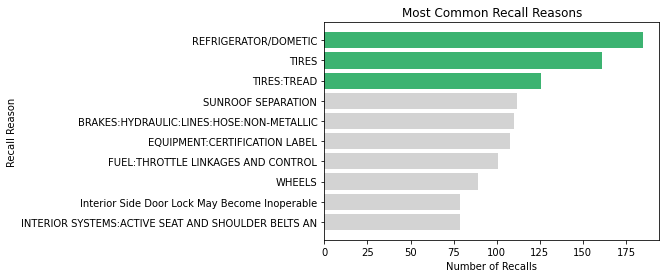

In [11]:
sub = df["subject"].value_counts().head(10)

colors = ['mediumseagreen' if val > 125 else 'lightgrey' for val in sub.values] #plot values
plt.barh(sub.index, sub.values, color=colors)
plt.gca().invert_yaxis()
plt.title("Most Common Recall Reasons")
plt.xlabel("Number of Recalls")
plt.ylabel("Recall Reason")
plt.show()

It seems that RVs with fridges are the cause for the most recalls. However, since an RV is a very limited sample of the population, the most profound reason for recalls would be tires, more specifically tires that leak air.

Let's group together different keywords to see if the leading causes is still in tires

In [12]:
def category(subject): #generated by copilot
    subject = str(subject).lower()
    
    if 'tire' in subject or 'tread' in subject or 'wheel' in subject:
        return 'Tires & Wheels'
    
    elif 'brake' in subject:
        return 'Braking System'
    
    elif 'air bag' in subject or 'airbag' in subject or 'seat belt' in subject:
        return 'Airbags & Seat Belts'
    
    elif 'fuel' in subject:
        return 'Fuel System'
    
    elif 'electrical' in subject or 'battery' in subject or 'software' in subject:
        return 'Electrical System'
    
    elif 'engine' in subject or 'power train' in subject or 'powertrain' in subject:
        return 'Engine & Powertrain'
    
    elif 'steering' in subject or 'suspension' in subject:
        return 'Steering & Suspension'
    
    elif 'refrigerator' in subject or 'dometic' in subject or 'cooling' in subject:
        return 'Refrigerators'
    
    elif 'label' in subject or 'certification' in subject or 'manual' in subject:
        return 'Labels & Documentation'
    
    else:
        return 'Other'

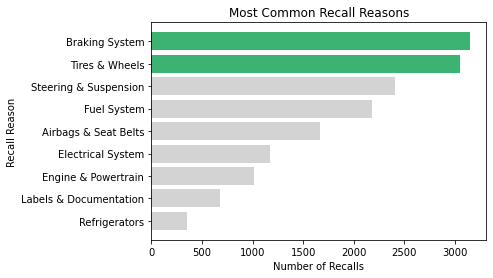

In [17]:
df["umbrella"] = df["subject"].apply(category) #apply gemini functino

cat = df["umbrella"].value_counts().tail(9) #remove other as it was ~14k of the results

colors = ['mediumseagreen' if val > 3000 else 'lightgrey' for val in cat.values]
plt.barh(cat.index, cat.values, color=colors)
plt.gca().invert_yaxis()
plt.title("Most Common Recall Reasons")
plt.xlabel("Number of Recalls")
plt.ylabel("Recall Reason")
plt.show()

With the "umbrella" analysis, we can see that braking systems account for the most amount of recalls. Tires, however, are still prevalent and have slightly less issues than brakes, but still a lot relative to other categories. As for refrigerators, since RVs have such a low proportion of the population, they are last in recalls.

#### Question 2:

Whats the average amount of vehicles affected per recall?

In [19]:
df["affected_count"].mean()

45296.460995989306

The average amount of vehicles affected is 45296. However, extreme values could skew this data, so let's check the median.

In [20]:
df["affected_count"].median()

679.0

As you can see, the median value is a lot lower than the average. To answer this question, let's make a boxplot to see the dispersion of data.

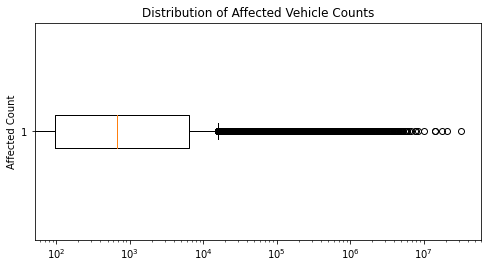

In [27]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["affected_count"].dropna(), vert=False)
plt.xscale("log")
plt.title("Distribution of Affected Vehicle Counts")
plt.ylabel("Affected Count")
plt.show()

It is shown that the upper fence of the dataset is around ~15k. This means anything above that number is an outlier, so we should rely on the median to more accurately depict how many vehicles are usually affected during recalls.

#### Question 3:
Which auto manufacturer is the least reliable (most # of recalls)

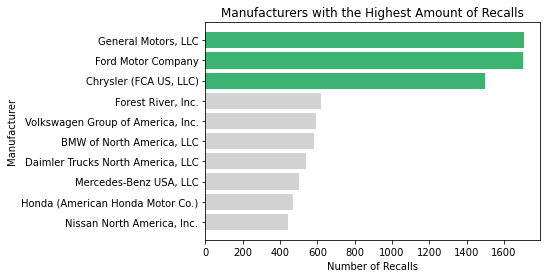

In [36]:
count = df["manufacturer"].value_counts().head(10) #same concept as getting the value counts in question 1

colors = ['mediumseagreen' if val > 1000 else 'lightgrey' for val in count.values]
plt.barh(count.index, count.values, color=colors)
plt.gca().invert_yaxis()
plt.title("Manufacturers with the Highest Amount of Recalls")
plt.xlabel("Number of Recalls")
plt.ylabel("Manufacturer")
plt.show()

All the American companies have the highest recall rates. This, however doesn't necessarily mean they are the most unreliable. As all the other companies are based overseas (except Forest River, but they are an RV company), there is a high likelyhood that recalls are more prevalent internationally, and they are able to fix the design before their vehicles come to the US market.

#### Question 4:
Has the amount of recalls gone up or down over the past 5 years

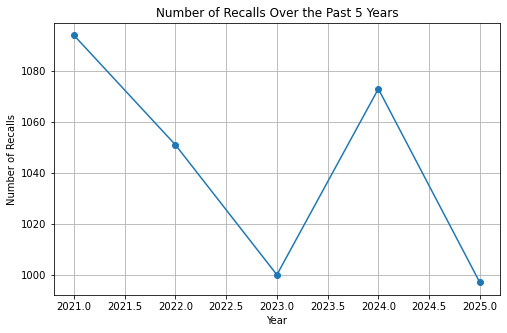

In [50]:
df["date"] = pd.to_datetime(df["report_date"]) #change format of date and put into new column
date = df[(df["date"].dt.year >= df["date"].dt.year.max() - 5) & (df["date"].dt.year < df["date"].dt.year.max())] #remove everything besides recalls from 2021-2025

recalls_per_year = (
    date.groupby(date["date"].dt.year) # group all recalls by year
    .size()
)

plt.figure(figsize=(8, 5)) #plot
plt.plot(recalls_per_year.index, recalls_per_year.values, marker="o")
plt.title("Number of Recalls Over the Past 5 Years")
plt.xlabel("Year")
plt.ylabel("Number of Recalls")
plt.grid(True)
plt.show()

While there was a downwards trend from 2021-2023, and a spike in 2024, the amount of recalls generally is hovering around 1000-1100.